In [8]:
import pandas as pd

In [9]:
BASE = "dados/employee_attrition.csv"

df = pd.read_csv(BASE)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [10]:
colunas_categoricas_nao_ordenadas = [
    "BusinessTravel", 
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

colunas_categoricas_ordenadas = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

coluna_alvo = ["Attrition"]

colunas_numericas = [
    coluna for coluna in df.columns if coluna not in (
        colunas_categoricas_nao_ordenadas + colunas_categoricas_ordenadas + coluna_alvo
    )
]

In [11]:
colunas_numericas

['Age',
 'DailyRate',
 'DistanceFromHome',
 'EmployeeCount',
 'EmployeeNumber',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'PercentSalaryHike',
 'StandardHours',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
faixas_idade = [0, 20, 30, 50, float("inf")] # (0-20], (20-30], (30,50] e (50-infinito]
rotulos = ["Adolescente", "Jovem adulto", "Adulto médio", "Adulto sênior"]

df["FaixaEtaria"] = pd.cut(df["Age"], bins=faixas_idade, labels=rotulos)

df[["Age", "FaixaEtaria"]].head(20)

,Age,FaixaEtaria
0,41,Adulto médio
1,49,Adulto médio
2,37,Adulto médio
3,33,Adulto médio
4,27,Jovem adulto
5,32,Adulto médio
6,59,Adulto sênior
7,30,Jovem adulto
8,38,Adulto médio
9,36,Adulto médio


In [14]:
df[["Age", "FaixaEtaria"]].tail(20)

,Age,FaixaEtaria
1450,35,Adulto médio
1451,38,Adulto médio
1452,50,Adulto médio
1453,36,Adulto médio
1454,45,Adulto médio
1455,40,Adulto médio
1456,35,Adulto médio
1457,40,Adulto médio
1458,35,Adulto médio
1459,29,Jovem adulto


In [16]:
df["FaixaEtaria"].value_counts()

FaixaEtaria
Adulto médio     941
Jovem adulto     358
Adulto sênior    143
Adolescente       28
Name: count, dtype: int64

In [17]:
df["FaixaEtaria"].value_counts().sort_index()

FaixaEtaria
Adolescente       28
Jovem adulto     358
Adulto médio     941
Adulto sênior    143
Name: count, dtype: int64

<Axes: xlabel='FaixaEtaria'>

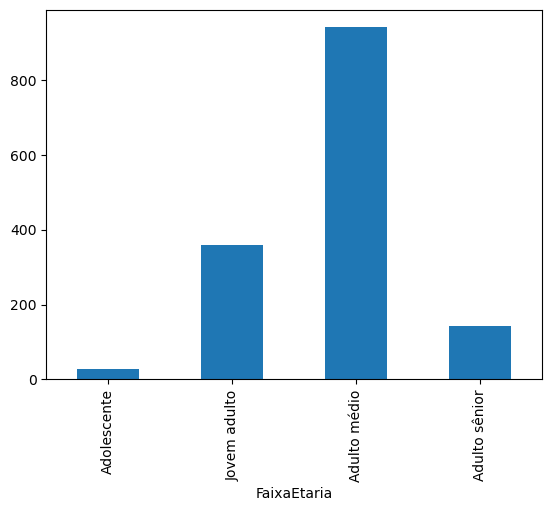

In [18]:
df["FaixaEtaria"].value_counts().sort_index().plot(kind="bar")

In [21]:
pd.crosstab(df["FaixaEtaria"], df["Attrition"], normalize="index").mul(100).round(1)

Attrition,No,Yes
FaixaEtaria,,
Adolescente,42.9,57.1
Jovem adulto,76.5,23.5
Adulto médio,87.4,12.6
Adulto sênior,87.4,12.6


In [22]:
colunas_categoricas_ordenadas.append("FaixaEtaria")

In [23]:
colunas_categoricas_ordenadas

['Education',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'WorkLifeBalance',
 'FaixaEtaria']

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'DailyRate'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'EmployeeCount'}>],
       [<Axes: title={'center': 'EmployeeNumber'}>,
        <Axes: title={'center': 'HourlyRate'}>,
        <Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyRate'}>],
       [<Axes: title={'center': 'NumCompaniesWorked'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>,
        <Axes: title={'center': 'StandardHours'}>,
        <Axes: title={'center': 'TotalWorkingYears'}>],
       [<Axes: title={'center': 'TrainingTimesLastYear'}>,
        <Axes: title={'center': 'YearsAtCompany'}>,
        <Axes: title={'center': 'YearsInCurrentRole'}>,
        <Axes: title={'center': 'YearsSinceLastPromotion'}>],
       [<Axes: title={'center': 'YearsWithCurrManager'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

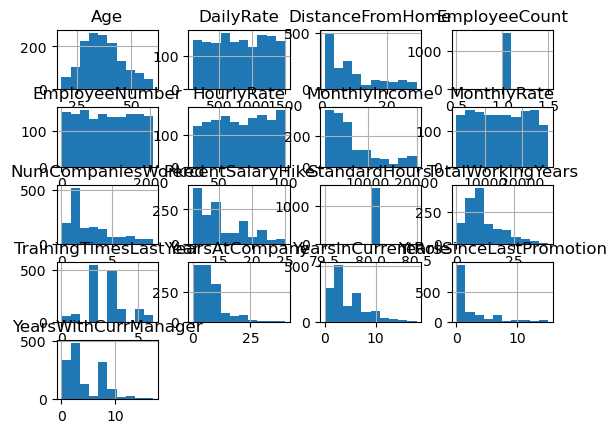

In [24]:
df[colunas_numericas].hist()

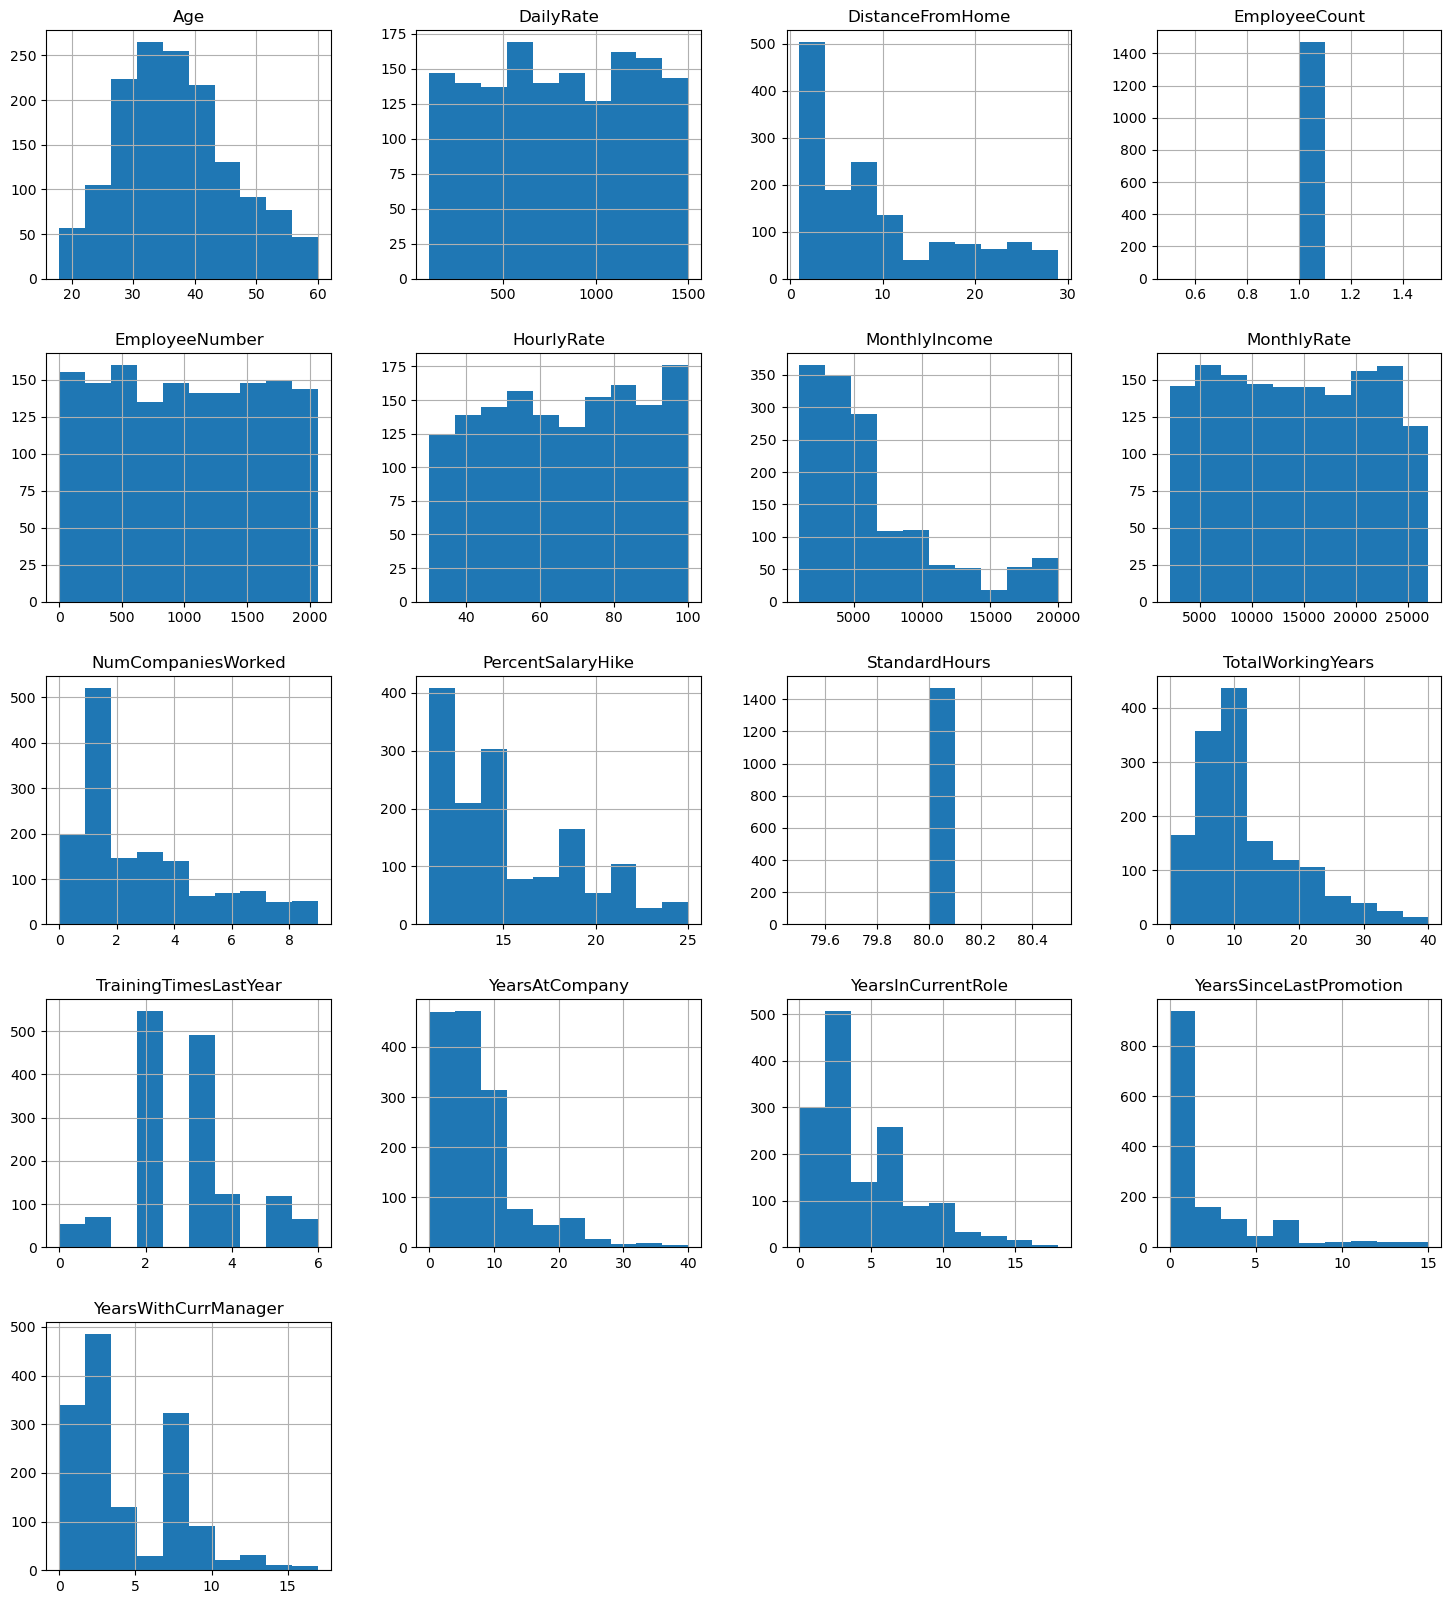

In [28]:
df[colunas_numericas].hist(figsize=(18, 20));